# Notebook 6
# Case Study Performance Benchmark

This notebook measures the computational benefit of activating the FEM pendulum only near contact.
It compares a full-FEM closed-loop run with a switched `MasterPendulum` run that uses the FMU away from contact and the FEM model near the wall.
The reported timing statistic is the median over repeated fresh runs.


## Imports and Repository Setup


In [1]:
from pathlib import Path
import sys

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent

sys.path.insert(0, str(_repo))
_repo

WindowsPath('c:/Users/flori/source/repos/FlorianFrech/SystemSimulation')

In [2]:
from dataclasses import dataclass
from functools import wraps
from time import perf_counter_ns
import gc
import platform

import numpy as np
import pandas as pd
from IPython.display import display

from plot_setup import FULL_WIDTH, METRIC_COLORS, REFERENCE_COLOR
from plot_setup import set_professional_style

plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, System, Connection, EventConnection

from OMPython import ModelicaSystem


## Benchmark Configuration

Use `N_REPEATS = 5` for the thesis result.
For a quick smoke test, set it temporarily to `1`.


In [3]:
T0 = 0.0
T_END = 0.4
MACRO_DT = 1e-3
FEM_INTERNAL_DT = 1e-3
CONTACT_STIFFNESS = 2e9
DWELL_TIME = 0.05
T_FEM_EARLIEST = 0.10
FEM_SWITCH_THRESHOLD_RAD = 0.075

N_WARMUP = 0
N_REPEATS = 1

OUT_DIR = _repo / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "n_warmup": N_WARMUP,
    "n_repeats": N_REPEATS,
    "t_end": T_END,
    "macro_dt": MACRO_DT,
    "fem_internal_dt": FEM_INTERNAL_DT,
    "contact_stiffness": CONTACT_STIFFNESS,
    "dwell_time": DWELL_TIME,
    "t_fem_earliest": T_FEM_EARLIEST,
    "fem_switch_threshold_rad": FEM_SWITCH_THRESHOLD_RAD,
}

BENCHMARK_ENV


{'python': '3.13.5',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 165 Stepping 2, GenuineIntel',
 'n_warmup': 0,
 'n_repeats': 1,
 't_end': 0.4,
 'macro_dt': 0.001,
 'fem_internal_dt': 0.001,
 'contact_stiffness': 2000000000.0,
 'dwell_time': 0.05,
 't_fem_earliest': 0.1,
 'fem_switch_threshold_rad': 0.075}

## Discover FMUs


In [4]:
PLATFORM = sys.platform
DEMO_DIR = _repo / "demos" / "ControlledPendulum"
PACKAGE_PATH = Path(DEMO_DIR / "src/modelica/ControlledPendulum")
FMU_DIR = DEMO_DIR / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths.keys())


['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Modelica Reference Simulation

In [5]:
reference = ModelicaSystem(fileName=str(PACKAGE_PATH / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset':'true'})
reference.buildModel()
reference.simulate(simargs={
    'startTime': T0,
    'stopTime': T_END,
    'stepSize': MACRO_DT,
})
ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'pid.I_out', 'pendulum.contact')
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Shared Helpers


In [6]:
def scalar_value(value):
    if isinstance(value, dict):
        value = value.get("value", np.nan)
    if hasattr(value, "magnitude"):
        value = value.magnitude
    return float(value)


def make_fem_parameters():
    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = 0.0

    sim_params = config.SimulationParameters()
    sim_params.tau = FEM_INTERNAL_DT
    sim_params.t_end = T_END
    sim_params.with_contact = True
    sim_params.use_gravity = True

    anim_params = config.AnimationParameters()
    anim_params.animate = False

    return {
        "init_params": init_params,
        "sim_params": sim_params,
        "anim_params": anim_params,
    }


PLANT_DIRECT_FEEDTHROUGH = {
    "theta": set(),
    "omega": set(),
    "alpha": {"tau"},
}


def declare_plant_feedthrough(component):
    """Declare plant feedthrough before System.initialize().

    System.initialize() needs feedthrough metadata before it initializes
    pure-Python components. The FEM plant cannot be safely perturbed before
    its torque boundary has been assembled, so the known map is declared here.
    """
    component.direct_feedthrough = {
        out_name: set(inputs)
        for out_name, inputs in PLANT_DIRECT_FEEDTHROUGH.items()
    }
    return component


def wall_contact_indicator(comp) -> float:
    theta = scalar_value(comp.get_outputs()["theta"])
    theta_wall = 0.0
    return theta - theta_wall


class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths["Controllers"]["PIDControllerReset_euler"]
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0.0)
        self.set_inputs({"resetI": False})


## Timing Helpers

- `run_s` measures the accepted call to `System.run()`.

- `fem_wall_s` measures the accumulated wall time spent in `FEMPendulum._do_step_internal()`.
- We instrument `_do_step_internal` (not `do_step`) because the hybrid algorithm calls
`_do_step_internal` directly on event sources — for trial steps in `_detect_crossings`,
for bisection iterations in `_locate_event_time`, and for the post-localization
event-collection re-step.
- Wrapping `do_step` would miss all of those calls in the full-FEM case (where `FEMPendulum` is the event source) but catch them in the switched case (where they go through `MasterPendulum.active_comp.do_step`), making the two cases incomparable.

- Wrapping `_do_step_internal` therefore captures **all** calls — trial, bisection,
event-collection, and accepted — in both configurations.

### Zero-step evaluations and `evaluate_outputs`

The step timers alone cannot explain where the run time goes, so two further measurements are taken.

**Zero-step split.** `CoSimComponent.evaluate_outputs()` performs its evaluation *by calling*
`self._do_step_internal(t, dt=0.0)` (see `syssimx/components/fmu.py`). Those calls therefore already
land inside `fem_wall_s` / `fmu_wall_s`. Each step timer now splits its total by `dt`:
`advancing_wall_s` for `dt > 0` and `zero_step_wall_s` for `dt == 0`. No time is counted twice, and
the zero-step share becomes visible instead of hiding inside the step total.

**Feedthrough evaluation.** `eval_wall_s` wraps `evaluate_outputs()` on every component in the
system, which additionally covers `set_inputs`, `_update_output_states`, `get_outputs`, and the Pint
magnitude conversion around the inner zero step. This *overlaps* the zero-step split above by
exactly the inner `_do_step_internal(dt=0)` call, so the non-overlapping part is

```
eval_overhead_s = eval_wall_s - zero_step_wall_s
```

which is the cost of the feedthrough machinery itself rather than of the model evaluation.

**Accounting.** `unaccounted_s = run_s - fem_wall_s - fmu_wall_s - eval_overhead_s - other_eval_wall_s`
is reported explicitly. It is the residual that the switched configuration was previously unable to
explain, and it is the quantity to drive down before any speedup claim is written.

In [7]:
@dataclass
class ComponentTimer:
    """Wall time inside a component's `_do_step_internal`, split by step kind.

    `evaluate_outputs()` evaluates by calling `_do_step_internal(dt=0.0)`, so
    those calls land here too. Splitting on `dt` keeps the advancing work and
    the feedthrough evaluations separable without counting anything twice.
    """

    label: str
    wall_ns: int = 0
    n_calls: int = 0
    requested_dt: float = 0.0
    zero_step_wall_ns: int = 0
    zero_step_calls: int = 0

    @property
    def wall_s(self):
        return self.wall_ns * 1e-9

    @property
    def zero_step_wall_s(self):
        """Portion of `wall_s` spent in zero-step (feedthrough) evaluations."""
        return self.zero_step_wall_ns * 1e-9

    @property
    def advancing_wall_s(self):
        """Portion of `wall_s` spent advancing simulation time."""
        return (self.wall_ns - self.zero_step_wall_ns) * 1e-9


@dataclass
class EvaluateTimer:
    """Wall time inside a component's `evaluate_outputs`.

    Overlaps `ComponentTimer.zero_step_wall_s` by the inner zero step. The
    difference is the feedthrough machinery around the model evaluation.
    """

    label: str
    wall_ns: int = 0
    n_calls: int = 0

    @property
    def wall_s(self):
        return self.wall_ns * 1e-9


def instrument_do_step_internal(comp, label):
    """Wrap the component's `_do_step_internal` with a timer.

    The hybrid algorithm reaches `_do_step_internal` directly on event-source
    components for trial, bisection, and event-collection steps. Wrapping
    here counts every solver call — accepted or rolled-back — making the
    full-FEM and switched cases comparable.
    """
    timer = ComponentTimer(label=label)
    original = comp._do_step_internal

    @wraps(original)
    def timed_internal(t, dt, *args, **kwargs):
        start = perf_counter_ns()
        try:
            return original(t, dt, *args, **kwargs)
        finally:
            elapsed = perf_counter_ns() - start
            timer.wall_ns += elapsed
            timer.n_calls += 1
            timer.requested_dt += float(dt)
            if float(dt) == 0.0:
                timer.zero_step_wall_ns += elapsed
                timer.zero_step_calls += 1

    comp._do_step_internal = timed_internal
    return timer


def instrument_evaluate_outputs(comp, label):
    """Wrap the component's `evaluate_outputs` with a timer.

    Feedthrough resolution and algebraic-loop iteration call this outside the
    stepping path, so its cost is invisible to `instrument_do_step_internal`
    except for the inner zero step it delegates to.
    """
    timer = EvaluateTimer(label=label)
    original = comp.evaluate_outputs

    @wraps(original)
    def timed_evaluate(inputs, t=None, *args, **kwargs):
        start = perf_counter_ns()
        try:
            return original(inputs, t, *args, **kwargs)
        finally:
            timer.wall_ns += perf_counter_ns() - start
            timer.n_calls += 1

    comp.evaluate_outputs = timed_evaluate
    return timer


def instrument_system_evaluate_outputs(system):
    """Instrument `evaluate_outputs` on every component of the system.

    Only top-level components are wrapped. A `MasterPendulum` delegates to its
    active sub-model, so wrapping the wrapper already captures the delegated
    call; wrapping the sub-models as well would double-count.
    """
    return {name: instrument_evaluate_outputs(comp, name) for name, comp in system.components.items()}


def summarize_eval_timers(eval_timers, plant_name):
    """Split feedthrough evaluation cost into the plant and everything else."""
    plant = eval_timers.get(plant_name)
    others = [t for name, t in eval_timers.items() if name != plant_name]
    return {
        "plant_eval_wall_s": plant.wall_s if plant else 0.0,
        "plant_eval_calls": plant.n_calls if plant else 0,
        "other_eval_wall_s": sum(t.wall_s for t in others),
        "other_eval_calls": sum(t.n_calls for t in others),
    }


def fem_active_time(sync_events, initial_mode, t0, t_end):
    active_mode = initial_mode
    left = t0
    total = 0.0

    for event in sync_events:
        right = float(event["time"])
        if active_mode == "FEM":
            total += max(0.0, right - left)
        active_mode = event["to_mode"]
        left = right

    if active_mode == "FEM":
        total += max(0.0, t_end - left)

    return total


def build_mode_intervals(sync_events, initial_mode, t0, t_end):
    rows = []
    active_mode = initial_mode
    left = t0

    for event in sync_events:
        right = float(event["time"])
        rows.append((left, right, active_mode))
        active_mode = event["to_mode"]
        left = right

    rows.append((left, t_end, active_mode))
    return rows

## System Factory

Both benchmark cases use the same closed-loop environment.
Only the plant component is exchanged.


In [8]:
from syssimx.core.base import CoSimComponent


def create_common_components():
    setpoint = FMUComponent(
        name="Setpoint",
        fmu_path=fmu_paths["Trajectories"]["SetPoint"],
        group="Reference",
    )

    pid = PIDController(name="PID")

    drive = FMUComponent(
        name="Drive",
        fmu_path=fmu_paths["Actuators"]["DriveDynamic"],
        group="Actuator",
    )

    angle_sensor = FMUComponent(
        name="Angle Sensor",
        fmu_path=fmu_paths["Sensors"]["AngleSensor"],
        group="Sensors",
    )

    angle_decoder = FMUComponent(
        name="Angle Decoder",
        fmu_path=fmu_paths["Sensors"]["AngleDecoder"],
        group="Signal Processing",
    )

    return setpoint, pid, drive, angle_sensor, angle_decoder


def assemble_system(plant: CoSimComponent, *, case_name, initial_mode):
    setpoint, pid, drive, angle_sensor, angle_decoder = create_common_components()

    plant.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

    connections = [
        Connection(setpoint.name, setpoint.output_specs["theta_ref"].name, pid.name, pid.input_specs["theta_ref"].name),
        Connection(plant.name, plant.output_specs["theta"].name, angle_sensor.name, angle_sensor.input_specs["theta"].name),
        Connection(angle_sensor.name, angle_sensor.output_specs["v_out"].name, angle_decoder.name, angle_decoder.input_specs["v_in"].name),
        Connection(angle_decoder.name, angle_decoder.output_specs["theta"].name, pid.name, pid.input_specs["theta_meas"].name),
        Connection(pid.name, pid.output_specs["u"].name, drive.name, drive.input_specs["u_control"].name),
        Connection(drive.name, drive.output_specs["torque"].name, plant.name, plant.input_specs["tau"].name),
        Connection(plant.name, plant.output_specs["omega"].name, drive.name, drive.input_specs["omega"].name),
    ]

    event_connections = [
        EventConnection(plant.name, "wall_hit", plant.name, plant.input_specs["omega_invert"].name),
        EventConnection(plant.name, "wall_hit", pid.name, pid.input_specs["resetI"].name),
    ]

    system = System(name=case_name)
    for comp in [setpoint, pid, drive, plant, angle_decoder, angle_sensor]:
        system.add_component(comp)
    for conn in connections:
        system.add_connection(conn)
    for event_connection in event_connections:
        system.add_event_connection(event_connection)

    system.initialize(t0=T0)

    system.algorithm.event_dedup_tol = 5e-4
    system.algorithm.tol_time = 1e-5

    return system, plant


## Benchmark Cases


In [9]:
def build_full_fem_case():
    plant = FEMPendulum(name="FEM_Pendulum", group="Plant")
    plant.set_parameters(**make_fem_parameters())
    declare_plant_feedthrough(plant)

    system, plant = assemble_system(
        plant,
        case_name="Performance Full FEM",
        initial_mode="FEM",
    )

    timers = {
        "fem": instrument_do_step_internal(plant, "FEM"),
        "fmu": ComponentTimer(label="FMU"),
    }
    # Instrumented after the step timers so that a wrapped evaluate_outputs
    # delegates into the already-wrapped _do_step_internal, keeping the
    # zero-step split consistent with the eval totals.
    eval_timers = instrument_system_evaluate_outputs(system)

    meta = {
        "case": "Full FEM",
        "initial_mode": "FEM",
        "t0": T0,
        "t_end": T_END,
        "dt": MACRO_DT,
        "plant_name": plant.name,
    }

    return system, plant, timers, eval_timers, meta

def build_switched_case():
    plant = MasterPendulum(
        name="MasterPendulum",
        initial_mode="FMU",
        fmu_solver="cvode",
    )
    plant.set_parameters(**{"FEM": make_fem_parameters()})
    declare_plant_feedthrough(plant)

    system, plant = assemble_system(
        plant,
        case_name="Performance Switched FMU FEM",
        initial_mode="FMU",
    )

    def fem_fmu_selector(t):
        # Time gate: never activate FEM before T_FEM_EARLIEST.
        if t <= T_FEM_EARLIEST:
            return "FMU"
        # Angle gate: activate FEM only when the pendulum is close to the wall.
        theta = scalar_value(plant.get_outputs()["theta"])
        if abs(theta) <= FEM_SWITCH_THRESHOLD_RAD:
            return "FEM"
        return "FMU"

    plant.mode_selector = fem_fmu_selector
    plant.hysteresis.dwell_time = DWELL_TIME
    plant._allow_mode_switching = True

    timers = {
        "fem": instrument_do_step_internal(plant.fem, "FEM"),
        "fmu": instrument_do_step_internal(plant.fmu, "FMU"),
    }
    eval_timers = instrument_system_evaluate_outputs(system)

    meta = {
        "case": "FMU/FEM switched",
        "initial_mode": "FMU",
        "t0": T0,
        "t_end": T_END,
        "dt": MACRO_DT,
        "plant_name": plant.name,
    }

    return system, plant, timers, eval_timers, meta

## Run One Case


In [10]:
def collect_outputs(system, plant, meta):
    history = system.get_history()
    t, data = history[plant.name]

    result = {
        "case": meta["case"],
        "t": np.asarray(t, dtype=float),
        "theta": np.asarray(data["theta"], dtype=float),
        "omega": np.asarray(data["omega"], dtype=float),
        "alpha": np.asarray(data["alpha"], dtype=float),
        "sync_events": getattr(plant, "sync_events", []),
        "initial_mode": meta["initial_mode"],
    }

    if isinstance(plant, MasterPendulum):
        result["mode_intervals"] = build_mode_intervals(
            plant.sync_events,
            initial_mode=meta["initial_mode"],
            t0=meta["t0"],
            t_end=meta["t_end"],
        )
    else:
        result["mode_intervals"] = [(meta["t0"], meta["t_end"], "FEM")]

    return result


def run_measured_case(build_case, case_name, repeat, *, warmup=False, keep_result=False):
    gc.collect()

    setup_start = perf_counter_ns()
    system, plant, timers, eval_timers, meta = build_case()
    setup_s = (perf_counter_ns() - setup_start) * 1e-9

    run_start = perf_counter_ns()
    system.run(meta["t0"], meta["t_end"], meta["dt"])
    run_s = (perf_counter_ns() - run_start) * 1e-9

    if isinstance(plant, MasterPendulum):
        fem_active_sim_s = fem_active_time(
            plant.sync_events,
            initial_mode=meta["initial_mode"],
            t0=meta["t0"],
            t_end=meta["t_end"],
        )
        n_switches = len(plant.sync_events)
    else:
        fem_active_sim_s = meta["t_end"] - meta["t0"]
        n_switches = 0

    eval_summary = summarize_eval_timers(eval_timers, meta["plant_name"])

    # evaluate_outputs delegates to _do_step_internal(dt=0), so the two step
    # timers already contain that inner cost. Subtract it once to obtain the
    # feedthrough machinery cost without double counting.
    zero_step_wall_s = timers["fem"].zero_step_wall_s + timers["fmu"].zero_step_wall_s
    eval_overhead_s = max(0.0, eval_summary["plant_eval_wall_s"] - zero_step_wall_s)

    row = {
        "case": case_name,
        "repeat": repeat,
        "warmup": warmup,
        "setup_s": setup_s,
        "run_s": run_s,
        "total_s": setup_s + run_s,
        "fem_wall_s": timers["fem"].wall_s,
        "fmu_wall_s": timers["fmu"].wall_s,
        "fem_calls": timers["fem"].n_calls,
        "fmu_calls": timers["fmu"].n_calls,
        "fem_requested_dt": timers["fem"].requested_dt,
        "fmu_requested_dt": timers["fmu"].requested_dt,
        # Zero-step (feedthrough) portion already included in the wall totals.
        "fem_zero_step_wall_s": timers["fem"].zero_step_wall_s,
        "fmu_zero_step_wall_s": timers["fmu"].zero_step_wall_s,
        "fem_zero_step_calls": timers["fem"].zero_step_calls,
        "fmu_zero_step_calls": timers["fmu"].zero_step_calls,
        # evaluate_outputs, and the non-overlapping feedthrough machinery.
        **eval_summary,
        "eval_overhead_s": eval_overhead_s,
        "unaccounted_s": (
            run_s
            - timers["fem"].wall_s
            - timers["fmu"].wall_s
            - eval_overhead_s
            - eval_summary["other_eval_wall_s"]
        ),
        "fem_active_sim_s": fem_active_sim_s,
        "n_switches": n_switches,
        "t_end": meta["t_end"],
        "dt": meta["dt"],
    }

    result = collect_outputs(system, plant, meta) if keep_result else None
    return row, result

## Execute Benchmark

The warm-up runs are excluded from the summary.
The first evaluated run of each case is kept for trajectory plotting.


In [11]:

case_builders = {
    "Full FEM": build_full_fem_case,
    "FMU/FEM switched": build_switched_case,
}

rows = []
representative_results = {}

for i in range(N_WARMUP):
    for case_name, builder in case_builders.items():
        print(f"warmup {i + 1}/{N_WARMUP}: {case_name}")
        row, _ = run_measured_case(builder, case_name, i, warmup=True, keep_result=False)
        rows.append(row)

for i in range(N_REPEATS):
    for case_name, builder in case_builders.items():
        keep_result = i == 0
        print(f"repeat {i + 1}/{N_REPEATS}: {case_name}")
        row, result = run_measured_case(builder, case_name, i, warmup=False, keep_result=keep_result)
        rows.append(row)
        if keep_result:
            representative_results[case_name] = result

df_runs = pd.DataFrame(rows)
df_eval = df_runs.loc[~df_runs["warmup"]].copy()

display(df_eval)


repeat 1/1: Full FEM
repeat 1/1: FMU/FEM switched


,case,repeat,warmup,setup_s,run_s,total_s,fem_wall_s,fmu_wall_s,fem_calls,fmu_calls,...,plant_eval_wall_s,plant_eval_calls,other_eval_wall_s,other_eval_calls,eval_overhead_s,unaccounted_s,fem_active_sim_s,n_switches,t_end,dt
0,Full FEM,0,False,2.250174,610.010752,612.260925,598.442406,0.00000,861,0,...,0.0,0,0.0,0,0.0,11.568345,0.400,0,0.4,0.001
1,FMU/FEM switched,0,False,2.884688,371.114153,373.998841,294.727248,0.02572,441,424,...,0.0,0,0.0,0,0.0,76.361184,0.188,2,0.4,0.001


## Timing Summary


In [12]:
def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)


summary = (
    df_eval
    .groupby("case", sort=False)
    .agg(
        run_median_s=("run_s", "median"),
        run_q25_s=("run_s", q25),
        run_q75_s=("run_s", q75),
        fem_wall_median_s=("fem_wall_s", "median"),
        fmu_wall_median_s=("fmu_wall_s", "median"),
        fem_active_sim_median_s=("fem_active_sim_s", "median"),
        fem_calls_median=("fem_calls", "median"),
        n_switches_median=("n_switches", "median"),
    )
)

full_run_s = summary.loc["Full FEM", "run_median_s"]
full_fem_wall_s = summary.loc["Full FEM", "fem_wall_median_s"]

summary["run_speedup"] = full_run_s / summary["run_median_s"]
summary["fem_wall_speedup"] = full_fem_wall_s / summary["fem_wall_median_s"]
summary["fem_wall_share"] = summary["fem_wall_median_s"] / summary["run_median_s"]
summary["fem_active_sim_share"] = summary["fem_active_sim_median_s"] / T_END

summary_display = summary.copy()
display(
    summary_display.style.format({
        "run_median_s": "{:.3f}",
        "run_q25_s": "{:.3f}",
        "run_q75_s": "{:.3f}",
        "fem_wall_median_s": "{:.3f}",
        "fmu_wall_median_s": "{:.3f}",
        "fem_active_sim_median_s": "{:.3f}",
        "fem_calls_median": "{:.0f}",
        "n_switches_median": "{:.0f}",
        "run_speedup": "{:.2f}",
        "fem_wall_speedup": "{:.2f}",
        "fem_wall_share": "{:.1%}",
        "fem_active_sim_share": "{:.1%}",
    })
)

,run_median_s,run_q25_s,run_q75_s,fem_wall_median_s,fmu_wall_median_s,fem_active_sim_median_s,fem_calls_median,n_switches_median,run_speedup,fem_wall_speedup,fem_wall_share,fem_active_sim_share
case,,,,,,,,,,,,
Full FEM,610.011,610.011,610.011,598.442,0.000,0.400,861,0,1.00,1.00,98.1%,100.0%
FMU/FEM switched,371.114,371.114,371.114,294.727,0.026,0.188,441,2,1.64,2.03,79.4%,47.0%


## Runtime Accounting

Where the wall time actually goes. Every column is a disjoint share of `run_s`:

| Column | Meaning |
|---|---|
| `model_advancing_s` | FEM + FMU `_do_step_internal` with `dt > 0` |
| `model_zero_step_s` | FEM + FMU `_do_step_internal` with `dt == 0`, i.e. the model evaluation inside `evaluate_outputs` |
| `eval_overhead_s` | plant `evaluate_outputs` minus its inner zero step: the feedthrough machinery itself |
| `other_eval_wall_s` | `evaluate_outputs` on all non-plant components |
| `unaccounted_s` | residual — orchestration, port/unit handling, history, event bookkeeping |

A large `unaccounted_s` in the switched case relative to the full-FEM case is the gap to close
before any speedup number is written into the paper.

In [13]:
df_acc = df_eval.copy()
df_acc["model_advancing_s"] = (
    (df_acc["fem_wall_s"] - df_acc["fem_zero_step_wall_s"])
    + (df_acc["fmu_wall_s"] - df_acc["fmu_zero_step_wall_s"])
)
df_acc["model_zero_step_s"] = df_acc["fem_zero_step_wall_s"] + df_acc["fmu_zero_step_wall_s"]

accounting = (
    df_acc
    .groupby("case", sort=False)
    .agg(
        run_median_s=("run_s", "median"),
        model_advancing_s=("model_advancing_s", "median"),
        model_zero_step_s=("model_zero_step_s", "median"),
        eval_overhead_s=("eval_overhead_s", "median"),
        other_eval_wall_s=("other_eval_wall_s", "median"),
        unaccounted_s=("unaccounted_s", "median"),
        plant_eval_calls=("plant_eval_calls", "median"),
        other_eval_calls=("other_eval_calls", "median"),
        fem_zero_step_calls=("fem_zero_step_calls", "median"),
        fmu_zero_step_calls=("fmu_zero_step_calls", "median"),
    )
)
accounting["unaccounted_share"] = accounting["unaccounted_s"] / accounting["run_median_s"]

display(
    accounting.style.format({
        "run_median_s": "{:.3f}",
        "model_advancing_s": "{:.3f}",
        "model_zero_step_s": "{:.3f}",
        "eval_overhead_s": "{:.3f}",
        "other_eval_wall_s": "{:.3f}",
        "unaccounted_s": "{:.3f}",
        "plant_eval_calls": "{:.0f}",
        "other_eval_calls": "{:.0f}",
        "fem_zero_step_calls": "{:.0f}",
        "fmu_zero_step_calls": "{:.0f}",
        "unaccounted_share": "{:.1%}",
    })
)

# Per-model-call residual. The switched case previously carried roughly seven
# times the full-FEM per-call cost outside the models; that ratio is the
# anomaly being chased, and it should come down once the residual is explained.
for case in accounting.index:
    calls = df_acc.loc[df_acc["case"] == case, ["fem_calls", "fmu_calls"]].median().sum()
    residual_ms = 1e3 * accounting.loc[case, "unaccounted_s"] / max(1.0, calls)
    print(f"{case:<20} unaccounted per model call: {residual_ms:8.3f} ms  (over {calls:.0f} calls)")

,run_median_s,model_advancing_s,model_zero_step_s,eval_overhead_s,other_eval_wall_s,unaccounted_s,plant_eval_calls,other_eval_calls,fem_zero_step_calls,fmu_zero_step_calls,unaccounted_share
case,,,,,,,,,,,
Full FEM,610.011,598.442,0.000,0.000,0.000,11.568,0,0,0,0,1.9%
FMU/FEM switched,371.114,294.753,0.000,0.000,0.000,76.361,0,0,0,0,20.6%


Full FEM             unaccounted per model call:   13.436 ms  (over 861 calls)
FMU/FEM switched     unaccounted per model call:   88.279 ms  (over 865 calls)


## Trajectory Deviation Against Full FEM

The switched run is compared against the full-FEM run from the representative benchmark repetition.
This comparison checks whether the runtime speedup is obtained without changing the contact-relevant trajectory substantially.


In [14]:
def trajectory_error_metrics(t, y, t_ref, y_ref, *, t_min=None, t_max=None):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if t_min is not None:
        mask &= t >= t_min
    if t_max is not None:
        mask &= t <= t_max

    t_eval = t[mask]
    y_eval = y[mask]
    y_ref_eval = np.interp(t_eval, t_ref, y_ref)
    err = y_eval - y_ref_eval
    duration = t_eval[-1] - t_eval[0]

    return {
        "e_inf": np.max(np.abs(err)),
        "e_2": np.sqrt(np.trapezoid(err**2, t_eval) / duration),
        "e_mean": np.mean(np.abs(err)),
        "n_samples": len(t_eval),
    }


full = representative_results["Full FEM"]
switched = representative_results["FMU/FEM switched"]
contact_window = (switched['mode_intervals'][1][0],
                  switched['mode_intervals'][1][1])


metrics_full = trajectory_error_metrics(
    switched["t"],
    switched["theta"],
    full["t"],
    full["theta"],
)

metrics_contact = trajectory_error_metrics(
    switched["t"],
    switched["theta"],
    full["t"],
    full["theta"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

error_table = pd.DataFrame([
    {"quantity": r"$\\theta$", "interval": "full horizon", **metrics_full},
    {"quantity": r"$\\theta$", "interval": "contact window", **metrics_contact},
])

display(
    error_table.style.format({
        "e_inf": "{:.3e}",
        "e_2": "{:.3e}",
        "e_mean": "{:.3e}",
        "n_samples": "{:.0f}",
    })
)


,quantity,interval,e_inf,e_2,e_mean,n_samples
0,$\\theta$,full horizon,3.343e-02,9.019e-03,5.412e-03,414
1,$\\theta$,contact window,3.343e-02,1.239e-02,8.976e-03,201


## Thesis Table Output


In [15]:
timing_table = summary.reset_index().rename(columns={"case": "Case"})[
    [
        "Case",
        "run_median_s",
        "fem_wall_median_s",
        "fem_active_sim_median_s",
        "run_speedup",
        "fem_active_sim_share",
        "n_switches_median",
    ]
]

print(
    timing_table.to_latex(
        index=False,
        escape=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

print(
    error_table.to_latex(
        index=False,
        escape=False,
        float_format=lambda x: f"{x:.3e}" if abs(x) < 1 else f"{x:.3f}",
    )
)


\begin{tabular}{lrrrrrr}
\toprule
Case & run_median_s & fem_wall_median_s & fem_active_sim_median_s & run_speedup & fem_active_sim_share & n_switches_median \\
\midrule
Full FEM & 610.011 & 598.442 & 0.400 & 1.000 & 1.000 & 0.000 \\
FMU/FEM switched & 371.114 & 294.727 & 0.188 & 1.644 & 0.470 & 2.000 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
quantity & interval & e_inf & e_2 & e_mean & n_samples \\
\midrule
$\\theta$ & full horizon & 3.343e-02 & 9.019e-03 & 5.412e-03 & 414 \\
$\\theta$ & contact window & 3.343e-02 & 1.239e-02 & 8.976e-03 & 201 \\
\bottomrule
\end{tabular}



## Thesis Figure


--------

In [16]:
# Trajectory styles for §6.5.3 performance figure.
FULL_FEM_STYLE = dict(color="#1a1a1a", linewidth=1.8, linestyle="-",         zorder=4)
SWITCHED_STYLE = dict(color="#B65A3C", linewidth=1.6, linestyle=(0, (4, 2)), zorder=5)
WALL_STYLE     = dict(color="0.45",    linewidth=1.0, linestyle=":")
GRID_STYLE     = dict(alpha=0.4)

# Sub-model colors (for §6.5.2 trajectory lines and shared "FEM region" band).
MODEL_COLORS = {
    "FEM":     "#1f77b4",
    "FMU":     "#2ca02c",
    "OpenSim": "#ff7f0e",
}

# Muted mode-strip palette (background context, never primary data).
MODE_STRIP_COLORS = {
    "FMU":     "#d6cfc2",   # warm light gray — neutral, cheap mode
    "FEM":     "#bbd8e8",   # light blue, same hue family as the FEM region band
    "OpenSim": "#f4d8a8",   # muted peach (kept for completeness; not active in §6.5.3)
}
MODE_TEXT_COLOR = "0.20"


# Bar-chart colors for §6.5.3 panel (c).
TIMING_TOTAL_COLOR = "#2F4858"
TIMING_FEM_COLOR   = MODEL_COLORS["FEM"]

PANEL_LABEL_STYLE = dict(
    fontweight="bold", fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2),
)

T_HORIZON = T_END - T0


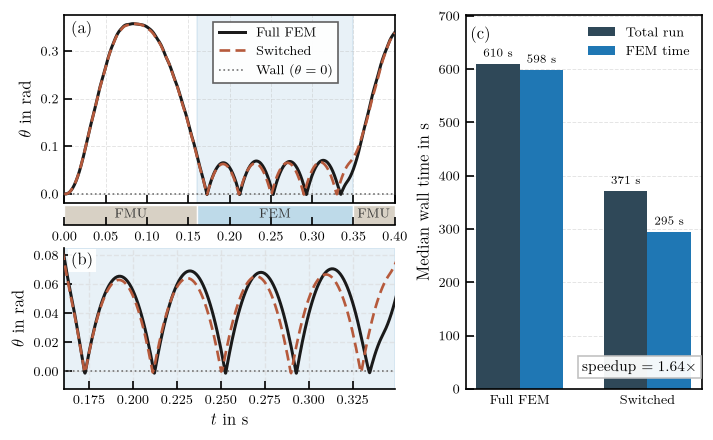

In [17]:
# --- Figure layout -----------------------------------------------------
fig = plt.figure(figsize=(FULL_WIDTH, 0.66 * FULL_WIDTH))

outer = fig.add_gridspec(
    1, 2,
    width_ratios=[1.4, 1.0],
    wspace=0.25,
    left=0.08, right=0.98, top=0.90, bottom=0.10,
)

left = outer[0, 0].subgridspec(
    4, 1,
    height_ratios=[3.2, 0.35, 0.32, 2.4],
    hspace=0.02,
)

ax_traj    = fig.add_subplot(left[0, 0])
ax_mode    = fig.add_subplot(left[1, 0], sharex=ax_traj)
ax_spacer  = fig.add_subplot(left[2, 0])
ax_contact = fig.add_subplot(left[3, 0])

ax_spacer.axis("off")

ax_time = fig.add_subplot(outer[0, 1])


# --- (a) Full-horizon trajectory ---------------------------------------
ax_traj.axvspan(*contact_window, color=MODEL_COLORS["FEM"], alpha=0.10, zorder=0)
ax_traj.plot(full["t"],     full["theta"],     label="Full FEM", **FULL_FEM_STYLE)
ax_traj.plot(switched["t"], switched["theta"], label="Switched", **SWITCHED_STYLE)
ax_traj.axhline(0, label=r"Wall ($\theta = 0$)", **WALL_STYLE)
ax_traj.set_xlim(T0, T_END)
ax_traj.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_traj.grid(True, **GRID_STYLE)
ax_traj.tick_params(axis="x", labelbottom=False)
x_ticks = ax_traj.get_xticks()
ax_traj.set_xticks([])
ax_traj.legend(
    loc="upper center", bbox_to_anchor=(0.64, 1),
    ncol=1, fontsize=8, frameon=True, handlelength=2.0, columnspacing=1.4,
)

# --- Mode strip --------------------------------------------------------
for t_left, t_right, mode in switched["mode_intervals"]:
    width = max(0.0, t_right - t_left)
    if width <= 0:
        continue
    ax_mode.broken_barh(
        [(t_left, width)],
        (0, 1),
        facecolors=MODE_STRIP_COLORS.get(mode, "0.75"),
        edgecolors="white", linewidth=0.8, alpha=0.95, zorder=0,
    )
    if width / T_HORIZON > 0.04:
        ax_mode.text(
            t_left + width / 2, 0.55,
            mode,
            ha="center", va="center",
            fontsize=8, color=MODE_TEXT_COLOR, fontweight="medium",
        )
ax_mode.set_ylim(0, 1)
ax_mode.set_yticks([])
ax_mode.set_xlim(T0, T_END)
ax_mode.set_xticks(x_ticks)
ax_mode.tick_params(axis="x", labelbottom=True)
ax_mode.grid(False)
for spine in ("left", "right", "top" ):
    ax_mode.spines[spine].set_visible(False)

# --- (b) Contact-window zoom ------------------------------------------
ax_contact.axvspan(*contact_window, color=MODEL_COLORS["FEM"], alpha=0.10, zorder=0)
ax_contact.plot(full["t"],     full["theta"],     **FULL_FEM_STYLE)
ax_contact.plot(switched["t"], switched["theta"], **SWITCHED_STYLE)
ax_contact.axhline(0, **WALL_STYLE)
ax_contact.set_xlim(*contact_window)
ax_contact.set_ylim(-0.012, 0.085)
ax_contact.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_contact.grid(True, color="0.85", alpha=0.6, linewidth=0.8)
for spine in ("top", "right"):
    ax_contact.spines[spine].set_visible(False)

# --- (c) Wall-clock bars -----------------------------------------------
x = np.arange(len(timing_table))
bar_w = 0.34
bars_total = ax_time.bar(x - bar_w/2, timing_table["run_median_s"],
                         width=bar_w, color=TIMING_TOTAL_COLOR, label="Total run")
bars_fem   = ax_time.bar(x + bar_w/2, timing_table["fem_wall_median_s"],
                         width=bar_w, color=TIMING_FEM_COLOR,   label="FEM time")
ax_time.bar_label(bars_total, fmt="%.0f s", fontsize=7, padding=3)
ax_time.bar_label(bars_fem,   fmt="%.0f s", fontsize=7, padding=3)
ax_time.set_xticks(x)
ax_time.set_xticklabels(["Full FEM", "Switched"])
ax_time.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax_time.set_ylim(0, timing_table["run_median_s"].max() * 1.15)
ax_time.grid(True, axis="y", **GRID_STYLE)
ax_time.legend(loc="upper right", fontsize=8, frameon=False)

speedup = summary.loc["FMU/FEM switched", "run_speedup"]
ax_time.text(
    0.98, 0.04,
    rf"speedup $= {speedup:.2f}\times$",
    transform=ax_time.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5),
)

# --- Panel labels ------------------------------------------------------
for label, ax in [("(a)", ax_traj), ("(b)", ax_contact), ("(c)", ax_time)]:
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            ha="left", va="top", **PANEL_LABEL_STYLE)

fig.savefig(OUT_DIR / "06_performance_switching.pdf", bbox_inches="tight")
plt.show()


---------

## Interpretation Notes

Use the median run time for the thesis text.
The FEM wall time explains where the speedup comes from.
The trajectory error table checks that the switched run stays close to the full-FEM benchmark.
The mode strip shows whether the FEM model was active only in the contact-relevant part of the trajectory.


In [18]:
performance_summary = {
    "run_speedup": summary.loc["FMU/FEM switched", "run_speedup"],
    "full_fem_run_median_s": summary.loc["Full FEM", "run_median_s"],
    "switched_run_median_s": summary.loc["FMU/FEM switched", "run_median_s"],
    "switched_fem_active_share": summary.loc["FMU/FEM switched", "fem_active_sim_share"],
    "theta_e_inf_full": metrics_full["e_inf"],
    "theta_e_2_full": metrics_full["e_2"],
    "theta_e_inf_contact": metrics_contact["e_inf"],
    "theta_e_2_contact": metrics_contact["e_2"],
}

performance_summary

{'run_speedup': np.float64(1.6437280751119487),
 'full_fem_run_median_s': np.float64(610.0107517),
 'switched_run_median_s': np.float64(371.1141526),
 'switched_fem_active_share': np.float64(0.4700000000000003),
 'theta_e_inf_full': np.float64(0.03342674628988129),
 'theta_e_2_full': np.float64(0.009019053949087932),
 'theta_e_inf_contact': np.float64(0.03342674628988129),
 'theta_e_2_contact': np.float64(0.012387797680461063)}